<a href="https://colab.research.google.com/github/drmamckinney/Week2-GitHub-MarkMcKinney/blob/main/Assignment_Lab_6_2_Analyzing_Cybersecurity_or_Fraud_Detection_Mark_McKinney.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment Lab 6.2 – Analyzing a Cybersecurity or Fraud Detection Scenario Using Machine Learning

Mark McKinney

This assignment applies machine learning techniques to analyze fraudulent transaction activity, compare model performance, and evaluate how AI can support cybersecurity monitoring and threat detection.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
# Load the fraud detection dataset
df = pd.read_excel("creditcard.xlsx")

# Display the first five rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
# Review dataset structure
print("Dataset Shape:")
print(df.shape)

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Review class distribution
print("\nClass Distribution:")
print(df["Class"].value_counts())

Dataset Shape:
(284807, 31)

Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [7]:
# Define features and target variable
X = df.drop("Class", axis=1)
y = df["Class"]

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Scale feature values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data preparation complete.")

Data preparation complete.


In [8]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

# Generate Logistic Regression predictions
lr_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression model complete.")

Logistic Regression model complete.


In [9]:
# Calculate Logistic Regression evaluation metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print("Logistic Regression Results")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

Logistic Regression Results
Accuracy: 0.9991397773954567
Precision: 0.8266666666666667
Recall: 0.6326530612244898
F1 Score: 0.7167630057803468

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Generate Decision Tree predictions
dt_pred = dt_model.predict(X_test)

print("Decision Tree model complete.")

Decision Tree model complete.


In [11]:
# Calculate Decision Tree evaluation metrics
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)

print("Decision Tree Results")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall:", dt_recall)
print("F1 Score:", dt_f1)

print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

Decision Tree Results
Accuracy: 0.9991397773954567
Precision: 0.7525773195876289
Recall: 0.7448979591836735
F1 Score: 0.7487179487179487

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



In [12]:
# Compare model performance
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [lr_accuracy, dt_accuracy],
    "Precision": [lr_precision, dt_precision],
    "Recall": [lr_recall, dt_recall],
    "F1 Score": [lr_f1, dt_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.99914,0.826667,0.632653,0.716763
1,Decision Tree,0.99914,0.752577,0.744898,0.748718


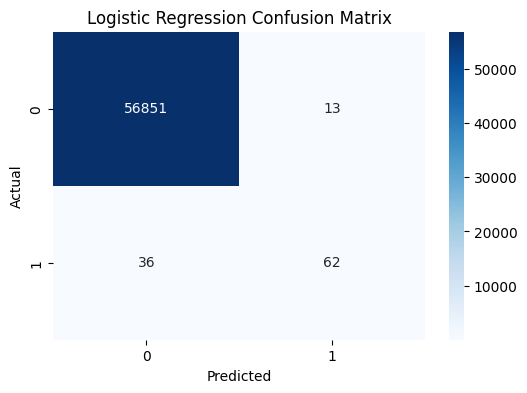

In [13]:
# Create Logistic Regression confusion matrix
lr_cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,4))
sns.heatmap(lr_cm, annot=True, fmt="d", cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

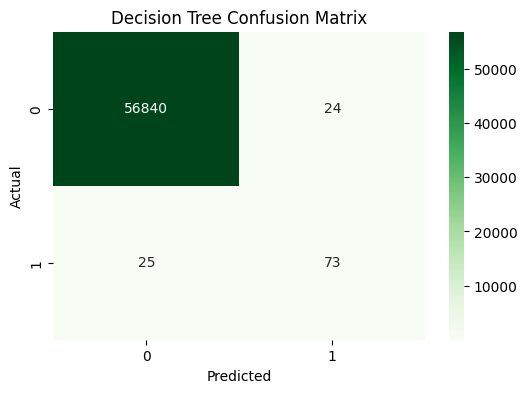

In [14]:
# Create Decision Tree confusion matrix
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))
sns.heatmap(dt_cm, annot=True, fmt="d", cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

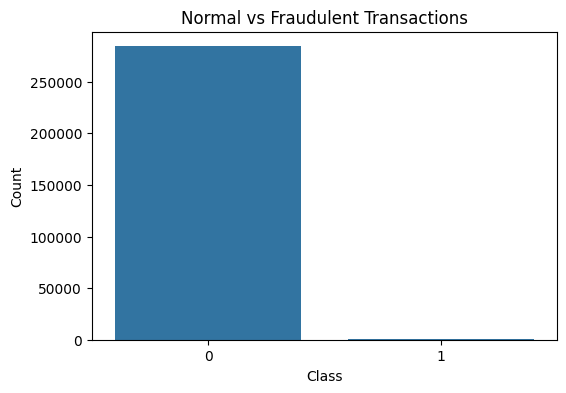

In [15]:
# Visualize normal vs fraudulent transactions
plt.figure(figsize=(6,4))

sns.countplot(
    x="Class",
    data=df
)

plt.title("Normal vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

In [16]:
# Review Decision Tree feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
17,V17,0.531364
14,V14,0.106662
12,V12,0.058690
10,V10,0.052289
26,V26,0.025286
4,V4,0.023158
20,V20,0.018705
27,V27,0.017594
21,V21,0.015792
16,V16,0.013004


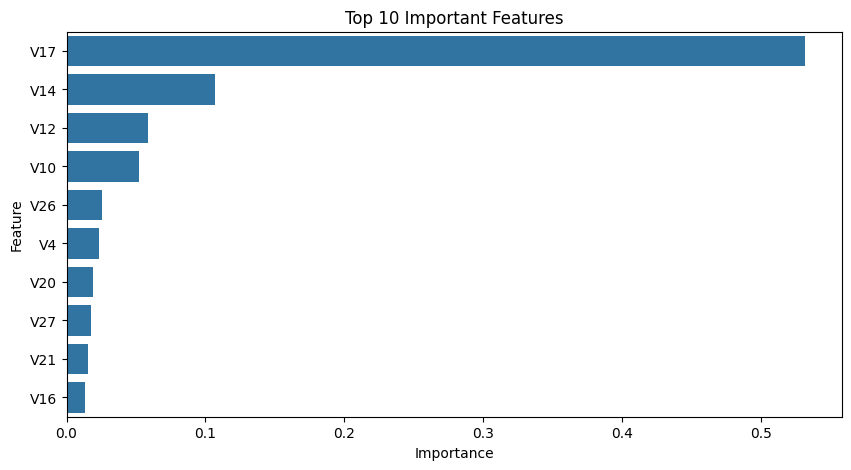

In [17]:
# Visualize top 10 important features
plt.figure(figsize=(10,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

## Interpretation of Findings

Two machine learning models were evaluated to identify fraudulent transactions within the dataset. Both Logistic Regression and Decision Tree achieved an accuracy of approximately 99.91%, demonstrating strong overall classification performance. However, additional evaluation metrics revealed meaningful differences between the models.

The Logistic Regression model achieved a precision score of 82.67%, indicating that most transactions identified as fraudulent were actually fraudulent. However, its recall score was 63.27%, meaning that a significant number of fraudulent transactions were not detected.

The Decision Tree model achieved a slightly lower precision score of 75.26% but produced a higher recall score of 74.49%. This indicates that the Decision Tree detected more fraudulent transactions while accepting a slightly higher number of false alarms. The Decision Tree also achieved the highest F1 Score at 74.87%, indicating a stronger overall balance between precision and recall.

The confusion matrices further demonstrated that both models performed exceptionally well when classifying legitimate transactions. However, the Decision Tree identified more fraudulent transactions than Logistic Regression, making it the preferred model for cybersecurity and fraud detection scenarios where identifying potential threats is a priority.

## Reflection Questions

### 1. Which machine learning model performed better and why?

The Decision Tree model performed better overall because it achieved a higher recall score and higher F1 Score than Logistic Regression. While both models achieved nearly identical accuracy, the Decision Tree detected more fraudulent transactions and provided a stronger balance between precision and recall.

### 2. What suspicious behaviors were identified in the dataset?

The dataset contained fraudulent transactions that differed from normal transaction behavior. Machine learning models identified these records as potential anomalies based on patterns learned during training.

### 3. Why is recall important in cybersecurity and fraud detection?

Recall measures a model's ability to identify malicious activity. In cybersecurity environments, high recall is important because missed threats may result in fraud, unauthorized access, financial loss, or other security incidents.

### 4. What do the confusion matrices reveal about model performance?

The confusion matrices show that both models correctly classified the vast majority of legitimate transactions. They also revealed the number of fraudulent transactions detected and the number that were missed. The Decision Tree detected more fraudulent transactions than Logistic Regression.

### 5. Which features appeared most important for identifying suspicious activity?

The Decision Tree feature importance analysis identified V17, V14, V12, and V10 as the most influential features. V17 was the dominant feature, accounting for more than half of the model's total importance.

### 6. How could machine learning improve cybersecurity monitoring?

Machine learning can continuously analyze large volumes of data, identify suspicious patterns, detect anomalies, prioritize alerts, and assist cybersecurity professionals in identifying threats more efficiently.

### 7. What are the risks of relying solely on AI for cybersecurity decisions?

AI systems may generate false positives and false negatives, miss emerging threats, or be affected by poor-quality training data. Human oversight remains necessary to validate findings and make informed security decisions.

### 8. What ethical considerations should organizations consider when using AI in cybersecurity?

Organizations should protect user privacy, reduce bias, ensure transparency, maintain accountability, and implement appropriate human oversight when deploying AI-driven cybersecurity systems.

### 9. Based on your analysis, would you recommend using machine learning for cybersecurity monitoring? Why or why not?

Yes. Based on the results of this analysis, machine learning can significantly improve cybersecurity monitoring by identifying suspicious behavior more quickly and consistently than manual analysis alone. While AI should not replace human analysts, it can serve as a valuable tool for threat detection, fraud prevention, and security monitoring.